# Plot median observed spectral index vs. dish size (multiple intrinsic alphas)

Loads the `DM_alpha_{dish_size}_{alpha_intrinsic}.nparray` files written by
`frb_pipeline.py` directly with `numpy` (no dependency on `frb_pipeline.py`
itself), computes the median of `alpha_observed` for each (dish size, alpha)
combination, and plots one line per `alpha_intrinsic` on a single median-alpha-
vs-dish-size figure.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

## Config -- edit these

In [2]:
DISH_SIZES = [10, 20, 40, 80, 160, 320, 640]
ALPHAS_INTRINSIC = [-1, -1.5, -2, -3, -4]

DATA_DIR = Path('DM_alpha')   # folder containing the .nparray files
OUT_PNG = 'median_alpha_vs_dish.png'

## Load median observed alpha per (dish size, alpha_intrinsic)

In [3]:
def _fmt(x):
    """Filename-safe numeric formatting, matching frb_pipeline.py -- e.g.
    12.0 -> '12', -1.5 -> '-1.5'."""
    return f"{x:g}"


def load_median_alpha(out_dir, dish_sizes, alpha_intrinsic):
    """Return (dish_sizes_found, medians, errs, ns) for the given dish
    sizes at a single alpha_intrinsic. errs is a MAD-based standard error
    of the median, computed from alpha_observed."""
    dish_found, medians, errs, ns = [], [], [], []

    for D in dish_sizes:
        path = out_dir / f"DM_alpha_{_fmt(D)}_{_fmt(alpha_intrinsic)}.nparray"
        if not path.exists():
            print(f"  [skip] missing file: {path}")
            continue

        with np.load(path) as data:
            alpha_obs = np.asarray(data["alpha_observed"])
        alpha_obs = alpha_obs[~np.isnan(alpha_obs)]

        if len(alpha_obs) == 0:
            print(f"  [skip] no valid alpha_observed values in: {path}")
            continue

        median = np.median(alpha_obs)
        mad = np.median(np.abs(alpha_obs - median))
        se = 1.253 * mad / np.sqrt(len(alpha_obs)) if len(alpha_obs) > 1 else 0.0

        dish_found.append(D)
        medians.append(median)
        errs.append(se)
        ns.append(len(alpha_obs))

    return np.array(dish_found), np.array(medians), np.array(errs), np.array(ns)

In [4]:
results = {}  # alpha_intrinsic -> (dish_sizes, medians, errs, ns)

for alpha_intrinsic in ALPHAS_INTRINSIC:
    print(f"alpha_intrinsic = {alpha_intrinsic}")
    dish_sizes, medians, errs, ns = load_median_alpha(DATA_DIR, DISH_SIZES, alpha_intrinsic)
    results[alpha_intrinsic] = (dish_sizes, medians, errs, ns)

    for D, m, e, n in zip(dish_sizes, medians, errs, ns):
        print(f"  D={D:>6g} m | N={n:>5d} | median alpha_observed = {m:.4f} +/- {e:.4f}")
    print()

alpha_intrinsic = -1
  D=    10 m | N= 2630 | median alpha_observed = -1.3575 +/- 0.0070
  D=    20 m | N= 4620 | median alpha_observed = -1.3404 +/- 0.0051
  D=    40 m | N= 4990 | median alpha_observed = -1.6592 +/- 0.0084
  D=    80 m | N= 4990 | median alpha_observed = -2.0667 +/- 0.0128
  D=   160 m | N= 4990 | median alpha_observed = -2.4690 +/- 0.0169
  D=   320 m | N= 4990 | median alpha_observed = -2.8292 +/- 0.0208
  D=   640 m | N= 4990 | median alpha_observed = -3.1507 +/- 0.0246

alpha_intrinsic = -1.5
  D=    10 m | N= 2090 | median alpha_observed = -1.9041 +/- 0.0088
  D=    20 m | N= 3410 | median alpha_observed = -1.8944 +/- 0.0068
  D=    40 m | N= 4990 | median alpha_observed = -1.9656 +/- 0.0063
  D=    80 m | N= 4990 | median alpha_observed = -2.3396 +/- 0.0105
  D=   160 m | N= 4990 | median alpha_observed = -2.7821 +/- 0.0153
  D=   320 m | N= 4990 | median alpha_observed = -3.1543 +/- 0.0188
  D=   640 m | N= 4990 | median alpha_observed = -3.4943 +/- 0.0230

al

## Plot -- one line per intrinsic alpha

Saved plot to median_alpha_vs_dish.png


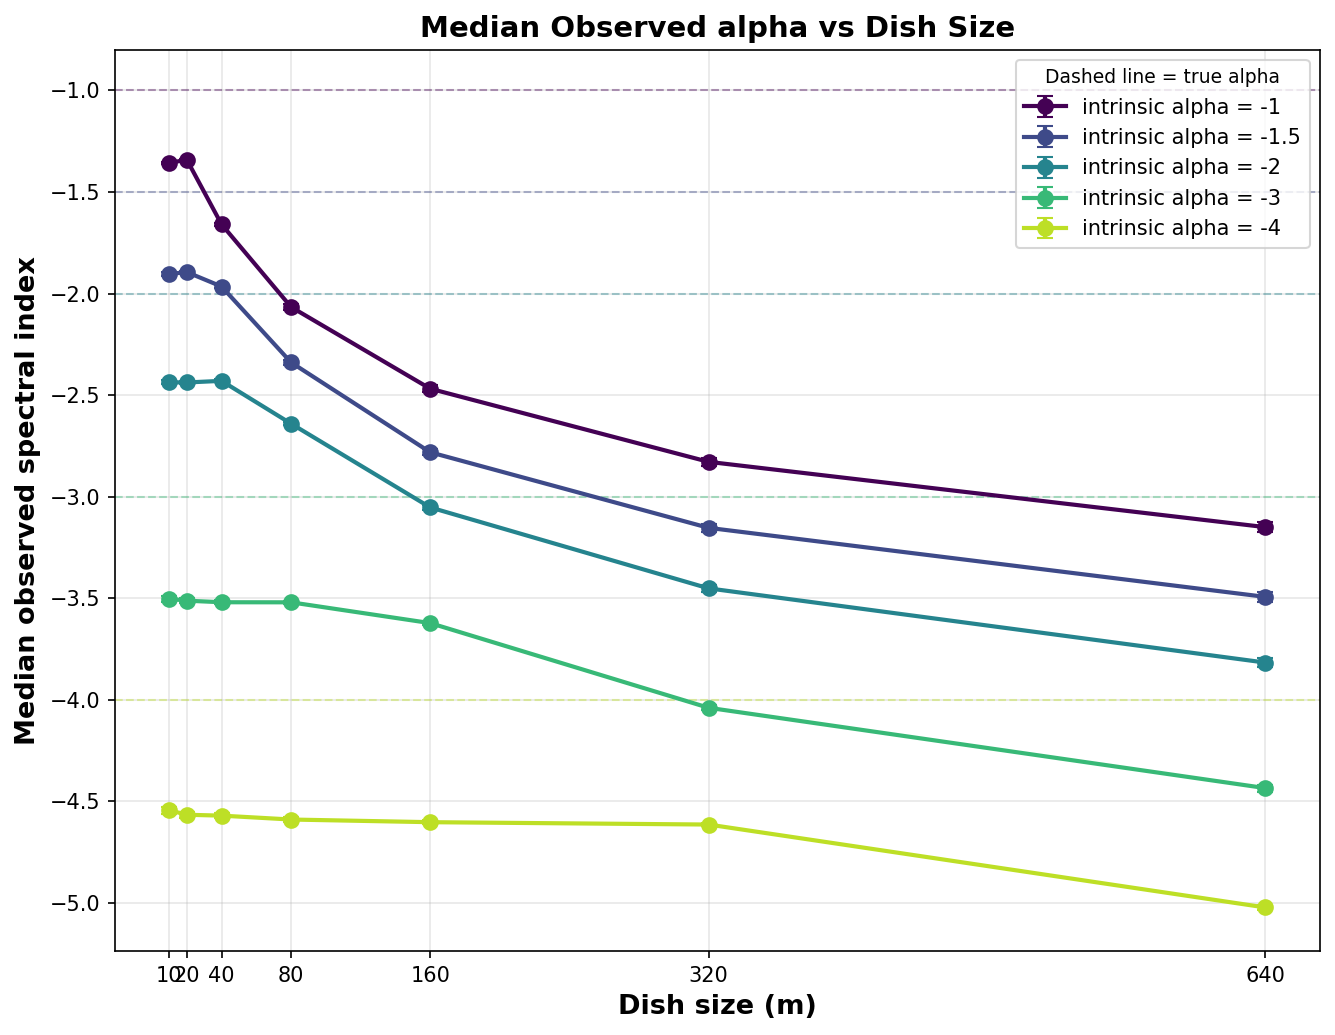

In [6]:
fig, ax = plt.subplots(figsize=(9, 7), dpi=150)

colors = plt.cm.viridis(np.linspace(0, 0.9, len(ALPHAS_INTRINSIC)))

for color, alpha_intrinsic in zip(colors, ALPHAS_INTRINSIC):
    dish_sizes, medians, errs, ns = results[alpha_intrinsic]
    if len(dish_sizes) == 0:
        continue

    ax.errorbar(dish_sizes, medians, yerr=errs, fmt="o-", markersize=7,
                linewidth=2, capsize=4, color=color,
                label=f"intrinsic alpha = {alpha_intrinsic}")
    # matching dashed reference line, same color, at the true value
    ax.axhline(alpha_intrinsic, color=color, linestyle="--", linewidth=1, alpha=0.4)

# ax.set_xscale("log", base=2)
ax.set_xticks(DISH_SIZES)
ax.set_xticklabels([f"{int(d)}" for d in DISH_SIZES])

ax.set_xlabel("Dish size (m)", fontsize=13, fontweight="bold")
ax.set_ylabel("Median observed spectral index", fontsize=13, fontweight="bold")
ax.set_title("Median Observed alpha vs Dish Size", fontsize=14, fontweight="bold")
ax.grid(True, alpha=0.3, which="both")
ax.legend(fontsize=10, title="Dashed line = true alpha", title_fontsize=9)

plt.tight_layout()
fig.savefig(OUT_PNG, bbox_inches="tight")
print(f"Saved plot to {OUT_PNG}")
plt.show()